<a href="https://colab.research.google.com/github/shriyashshitole/simple-ARIMA/blob/main/ARIMAv3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARIMA Time Series Forecasting for Stock Prices

In [ ]:
═══════════════════════════════════════════════════════════════════════════════
ARIMA STOCK PRICE FORECASTING MODEL - GOOGLE COLAB VERSION
═══════════════════════════════════════════════════════════════════════════════

This notebook implements a comprehensive ARIMA forecasting model for stock prices
with extensive logging, analysis, and customization options.

Author: Shriniwas Shitole
Institution: Pune Institute of Business Management
Course: Time Series Analysis and Forecasting
Model: ARIMA (AutoRegressive Integrated Moving Average)
═══════════════════════════════════════════════════════════════════════════════

# SECTION 1: INSTALLATION & IMPORTS

!pip install yfinance statsmodels -q

In [2]:
# Import libraries
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import yfinance as yf
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100

print("✅ All libraries imported successfully!")
print("=" * 80)

✅ All libraries imported successfully!


# SECTION 2: CONFIGURATION - CUSTOMIZE YOUR ANALYSIS HERE

In [7]:
print("\n📊 CONFIGURATION SECTION - Customize Your Analysis Here")
print("=" * 80)
print("⚙️ CUSTOMIZATION PARAMETERS - CHANGE THESE VALUES")


📊 CONFIGURATION SECTION - Customize Your Analysis Here
⚙️ CUSTOMIZATION PARAMETERS - CHANGE THESE VALUES


In [9]:
# Stock Configuration
STOCK_SYMBOL = 'AAPL'          # Stock ticker (e.g., 'AAPL', 'GOOGL', 'MSFT', 'TSLA', 'AMZN')
                               # Indian stocks: 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS'

# Data Configuration
TRAINING_DAYS = 365            # Number of historical days to use (e.g., 180, 365, 730)
FORECAST_DAYS = 30             # Number of days to predict (e.g., 7, 14, 30, 60, 90)

# Model Configuration
AUTO_ORDER = True              # True: Automatically find best parameters, False: Use manual order
MANUAL_ORDER = (1, 1, 1)       # Used only if AUTO_ORDER = False, format: (p, d, q)

# Analysis Configuration
PERFORM_EVALUATION = True      # Perform train-test split evaluation
TEST_SIZE = 0.2                # Proportion of data for testing (0.2 = 20%)
SHOW_ACF_PACF = True           # Show ACF/PACF plots
ACF_PACF_LAGS = 40             # Number of lags to display in ACF/PACF

# Visualization Configuration
PLOT_STYLE = 'detailed'        # 'detailed' or 'simple'
SAVE_RESULTS = True            # Save forecast to CSV file

# Logging Configuration
VERBOSE = True                 # Enable detailed logging

print(f"""
✓ Stock Symbol      : {STOCK_SYMBOL}
✓ Training Period   : {TRAINING_DAYS} days
✓ Forecast Horizon  : {FORECAST_DAYS} days
✓ Auto Order Search : {AUTO_ORDER}
✓ Manual Order      : {MANUAL_ORDER}
✓ Evaluation        : {PERFORM_EVALUATION}
✓ Verbose Logging   : {VERBOSE}
""")
print("=" * 80)


✓ Stock Symbol      : AAPL
✓ Training Period   : 365 days
✓ Forecast Horizon  : 30 days
✓ Auto Order Search : True
✓ Manual Order      : (1, 1, 1)
✓ Evaluation        : True
✓ Verbose Logging   : True



# SECTION 3: HELPER FUNCTIONS & LOGGING UTILITIES

In [10]:
def log_message(message, level="INFO"):
    """Enhanced logging with timestamps and icons"""
    if VERBOSE:
        timestamp = datetime.now().strftime('%H:%M:%S')
        symbols = {
            "INFO": "ℹ️",
            "SUCCESS": "✅",
            "WARNING": "⚠️",
            "ERROR": "❌",
            "PROCESS": "⚙️",
            "ANALYSIS": "📈",
            "RESULT": "📊"
        }
        symbol = symbols.get(level, "•")
        print(f"[{timestamp}] {symbol} {message}")

def print_header(title):
    """Print formatted section header"""
    print(f"\n{'=' * 80}")
    print(title.center(80))
    print(f"{'=' * 80}\n")

def print_separator():
    """Print separator line"""
    print(f"{'─' * 80}")

# SECTION 4: DATA FETCHING & PREPROCESSING

In [11]:
print_header("STEP 1: DATA FETCHING & PREPROCESSING")

log_message(f"Fetching {TRAINING_DAYS} days of data for {STOCK_SYMBOL}...", "PROCESS")

try:
    # Calculate date range
    end_date = datetime.now()
    start_date = end_date - timedelta(days=TRAINING_DAYS + 60)

    # Fetch stock data
    stock = yf.Ticker(STOCK_SYMBOL)
    data = stock.history(start=start_date, end=end_date)

    if data.empty:
        raise ValueError(f"No data found for symbol {STOCK_SYMBOL}")

    # Extract closing prices
    ts_data = data[['Close']].copy()
    ts_data.columns = ['Price']
    ts_data = ts_data.tail(TRAINING_DAYS)

    log_message(f"Successfully fetched {len(ts_data)} data points", "SUCCESS")
    log_message(f"Date range: {ts_data.index[0].strftime('%Y-%m-%d')} to {ts_data.index[-1].strftime('%Y-%m-%d')}", "INFO")

    # Calculate statistics
    stats = {
        'count': len(ts_data),
        'mean': ts_data['Price'].mean(),
        'std': ts_data['Price'].std(),
        'min': ts_data['Price'].min(),
        'max': ts_data['Price'].max(),
        'first_price': ts_data['Price'].iloc[0],
        'last_price': ts_data['Price'].iloc[-1],
        'price_change': ts_data['Price'].iloc[-1] - ts_data['Price'].iloc[0],
        'pct_change': ((ts_data['Price'].iloc[-1] - ts_data['Price'].iloc[0]) / ts_data['Price'].iloc[0]) * 100,
        'volatility': ts_data['Price'].pct_change().std() * 100
    }

    # Display statistics
    print_separator()
    print("DESCRIPTIVE STATISTICS".center(80))
    print_separator()
    print(f"   Total Data Points    : {stats['count']}")
    print(f"   Mean Price          : ${stats['mean']:.2f}")
    print(f"   Standard Deviation  : ${stats['std']:.2f}")
    print(f"   Minimum Price       : ${stats['min']:.2f}")
    print(f"   Maximum Price       : ${stats['max']:.2f}")
    print(f"   First Close Price   : ${stats['first_price']:.2f}")
    print(f"   Last Close Price    : ${stats['last_price']:.2f}")
    print(f"   Total Price Change  : ${stats['price_change']:+.2f}")
    print(f"   Percentage Change   : {stats['pct_change']:+.2f}%")
    print(f"   Daily Volatility    : {stats['volatility']:.2f}%")
    print_separator()

except Exception as e:
    log_message(f"Error fetching data: {str(e)}", "ERROR")
    raise


                     STEP 1: DATA FETCHING & PREPROCESSING                      

[07:39:37] ⚙️ Fetching 365 days of data for AAPL...
[07:39:38] ✅ Successfully fetched 291 data points
[07:39:38] ℹ️ Date range: 2024-12-09 to 2026-02-06
────────────────────────────────────────────────────────────────────────────────
                             DESCRIPTIVE STATISTICS                             
────────────────────────────────────────────────────────────────────────────────
   Total Data Points    : 291
   Mean Price          : $235.31
   Standard Deviation  : $26.38
   Minimum Price       : $171.83
   Maximum Price       : $286.19
   First Close Price   : $245.64
   Last Close Price    : $278.12
   Total Price Change  : $+32.48
   Percentage Change   : +13.22%
   Daily Volatility    : 1.97%
────────────────────────────────────────────────────────────────────────────────


# SECTION 5: DATA VISUALIZATION


                      STEP 2: VISUALIZING HISTORICAL DATA                       

[07:40:24] ⚙️ Creating time series plot...


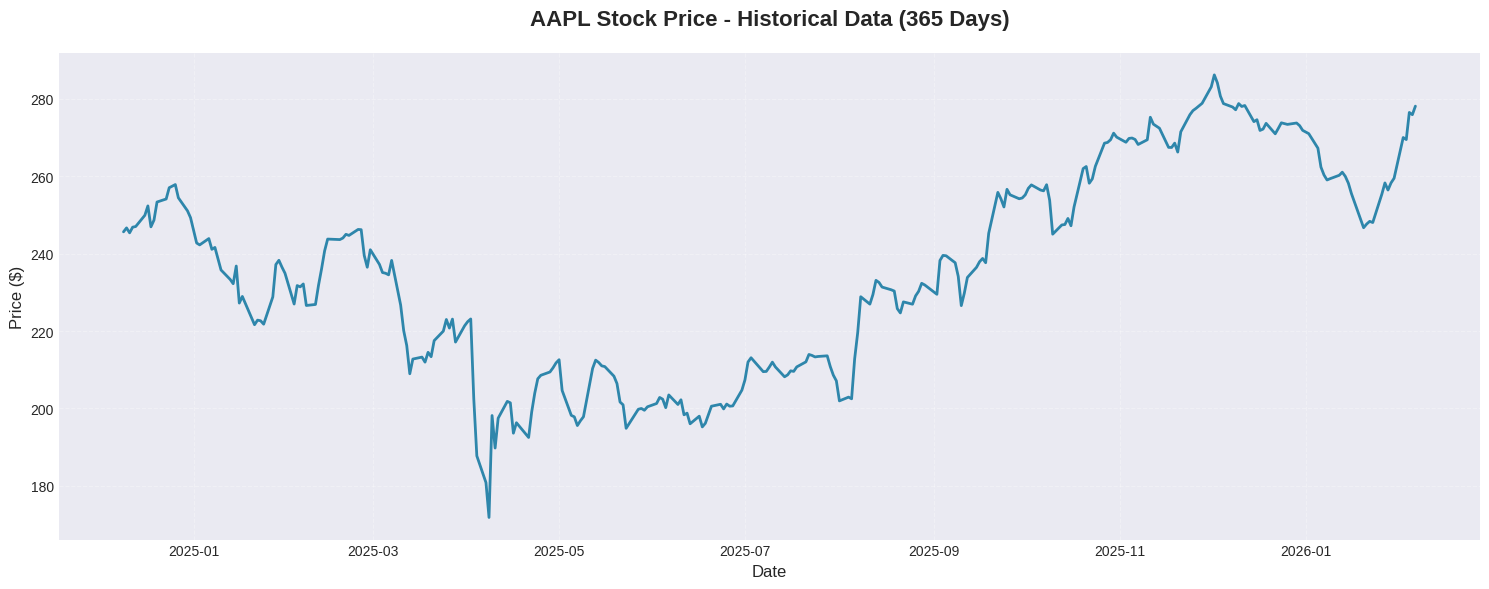

[07:40:25] ✅ Time series plot created successfully


In [12]:
print_header("STEP 2: VISUALIZING HISTORICAL DATA")

log_message("Creating time series plot...", "PROCESS")

plt.figure(figsize=(15, 6))
plt.plot(ts_data.index, ts_data['Price'], linewidth=2, color='#2E86AB')
plt.title(f'{STOCK_SYMBOL} Stock Price - Historical Data ({TRAINING_DAYS} Days)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

log_message("Time series plot created successfully", "SUCCESS")

# SECTION 6: STATIONARITY ANALYSIS (ADF TEST)

In [13]:
print_header("STEP 3: STATIONARITY ANALYSIS (ADF TEST)")

log_message("Performing Augmented Dickey-Fuller (ADF) test...", "ANALYSIS")

def check_stationarity(data, max_diff=2):
    """Perform ADF test and determine required differencing order"""
    diff_order = 0
    test_data = data.copy()

    for d in range(max_diff + 1):
        # Perform ADF test
        adf_result = adfuller(test_data.dropna())
        adf_statistic = adf_result[0]
        p_value = adf_result[1]
        critical_values = adf_result[4]

        print_separator()
        print(f"ADF Test Results (Differencing Order = {d})".center(80))
        print_separator()
        print(f"   ADF Statistic       : {adf_statistic:.6f}")
        print(f"   P-value            : {p_value:.6f}")
        print(f"   Critical Values:")
        for key, value in critical_values.items():
            print(f"      {key:>5} : {value:.6f}")

        is_stationary = p_value < 0.05
        print(f"\n   Status: {'✅ STATIONARY' if is_stationary else '❌ NON-STATIONARY'}")

        if is_stationary:
            print(f"   Decision: Series is stationary at d={d}")
            diff_order = d
            break
        else:
            print(f"   Decision: Differencing required")

            if d < max_diff:
                test_data = test_data.diff().dropna()
                diff_order = d + 1

    print_separator()

    return diff_order, p_value, is_stationary

differencing_order, adf_pvalue, is_stationary = check_stationarity(ts_data['Price'])

log_message(f"Required differencing order (d): {differencing_order}", "RESULT")


                    STEP 3: STATIONARITY ANALYSIS (ADF TEST)                    

[07:41:38] 📈 Performing Augmented Dickey-Fuller (ADF) test...
────────────────────────────────────────────────────────────────────────────────
                   ADF Test Results (Differencing Order = 0)                    
────────────────────────────────────────────────────────────────────────────────
   ADF Statistic       : -0.957838
   P-value            : 0.768330
   Critical Values:
         1% : -3.453423
         5% : -2.871699
        10% : -2.572183

   Status: ❌ NON-STATIONARY
   Decision: Differencing required
────────────────────────────────────────────────────────────────────────────────
                   ADF Test Results (Differencing Order = 1)                    
────────────────────────────────────────────────────────────────────────────────
   ADF Statistic       : -9.137623
   P-value            : 0.000000
   Critical Values:
         1% : -3.453423
         5% : -2.871699
        1

# SECTION 7: ACF AND PACF ANALYSIS


                          STEP 4: ACF & PACF ANALYSIS                           

[07:42:16] ⚙️ Generating ACF and PACF plots...


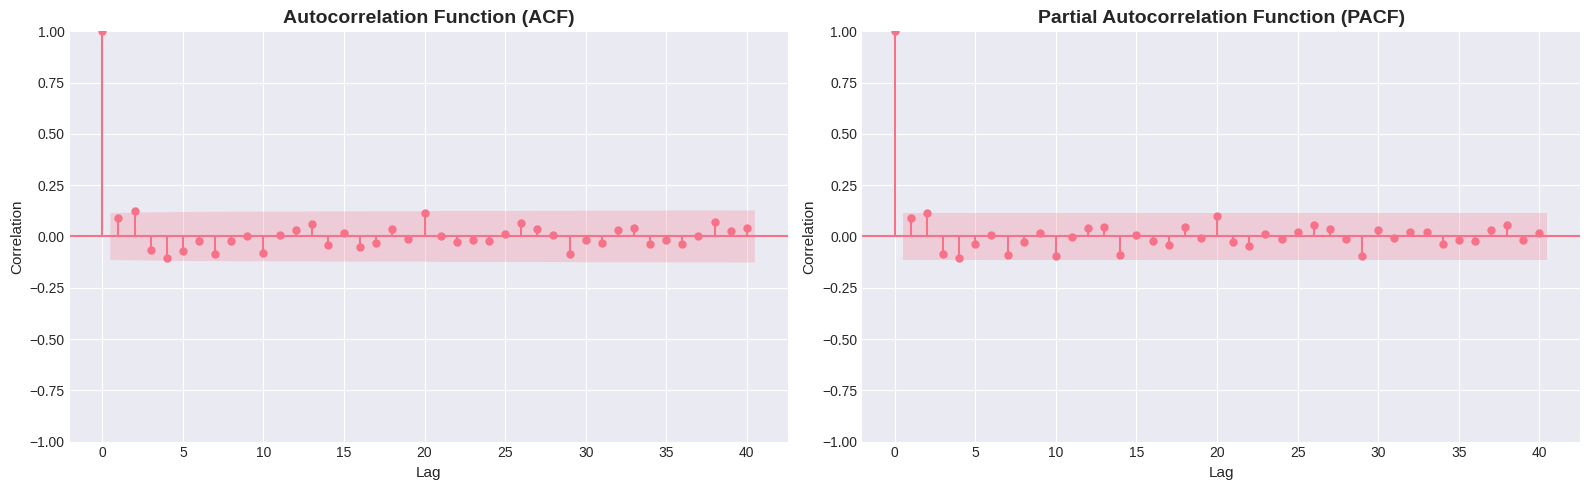

[07:42:17] ✅ ACF/PACF plots generated successfully

💡 Interpretation Guide:
   • ACF cuts off after lag q → MA(q) component
   • PACF cuts off after lag p → AR(p) component
   • Both decay gradually → ARMA model needed



In [15]:
if SHOW_ACF_PACF:
    print_header("STEP 4: ACF & PACF ANALYSIS")

    log_message("Generating ACF and PACF plots...", "PROCESS")

    # Prepare data for ACF/PACF
    acf_data = ts_data['Price'].copy()
    if differencing_order > 0:
        for i in range(differencing_order):
            acf_data = acf_data.diff()
        acf_data = acf_data.dropna()

    # Create plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # ACF Plot
    plot_acf(acf_data, lags=ACF_PACF_LAGS, ax=axes[0])
    axes[0].set_title('Autocorrelation Function (ACF)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Lag', fontsize=11)
    axes[0].set_ylabel('Correlation', fontsize=11)

    # PACF Plot
    plot_pacf(acf_data, lags=ACF_PACF_LAGS, ax=axes[1])
    axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Lag', fontsize=11)
    axes[1].set_ylabel('Correlation', fontsize=11)

    plt.tight_layout()
    plt.show()

    log_message("ACF/PACF plots generated successfully", "SUCCESS")

    print("\n💡 Interpretation Guide:")
    print("   • ACF cuts off after lag q → MA(q) component")
    print("   • PACF cuts off after lag p → AR(p) component")
    print("   • Both decay gradually → ARMA model needed\n")

# SECTION 8: MODEL FITTING

In [16]:
print_header("STEP 5: ARIMA MODEL FITTING")

def auto_arima_search(data, d):
    """Automatic ARIMA order selection using grid search"""
    log_message("Performing grid search for optimal parameters...", "PROCESS")

    p_range = range(0, 4)
    q_range = range(0, 4)

    best_aic = np.inf
    best_order = None

    total_iterations = len(p_range) * len(q_range)
    iteration = 0

    print(f"   Testing {total_iterations} parameter combinations...\n")

    for p in p_range:
        for q in q_range:
            iteration += 1
            try:
                model = ARIMA(data, order=(p, d, q))
                model_fit = model.fit()

                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_order = (p, d, q)
                    print(f"   [{iteration}/{total_iterations}] ✨ New best: ({p},{d},{q}) - AIC: {best_aic:.4f}")
            except:
                continue

    log_message(f"Best order found: {best_order} with AIC: {best_aic:.4f}", "SUCCESS")
    return best_order

# Determine ARIMA order
if AUTO_ORDER:
    arima_order = auto_arima_search(ts_data['Price'], differencing_order)
else:
    arima_order = MANUAL_ORDER
    log_message(f"Using manual order: {arima_order}", "INFO")

log_message(f"ARIMA Order: (p={arima_order[0]}, d={arima_order[1]}, q={arima_order[2]})", "INFO")

# Fit the model
try:
    model = ARIMA(ts_data['Price'], order=arima_order)
    model_fit = model.fit()

    print_separator()
    print("MODEL FIT SUMMARY".center(80))
    print_separator()
    print(f"   Model Order (p,d,q) : {arima_order}")
    print(f"   AIC                 : {model_fit.aic:.4f}")
    print(f"   BIC                 : {model_fit.bic:.4f}")
    print(f"   HQIC                : {model_fit.hqic:.4f}")
    print_separator()

    log_message("Model fitted successfully!", "SUCCESS")

except Exception as e:
    log_message(f"Error fitting model: {str(e)}", "ERROR")
    raise


                          STEP 5: ARIMA MODEL FITTING                           

[07:43:02] ⚙️ Performing grid search for optimal parameters...
   Testing 16 parameter combinations...

   [1/16] ✨ New best: (0,1,0) - AIC: 1657.9067
   [3/16] ✨ New best: (0,1,2) - AIC: 1653.7056


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


   [8/16] ✨ New best: (1,1,3) - AIC: 1652.9702


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


   [14/16] ✨ New best: (3,1,1) - AIC: 1652.9372


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


[07:43:04] ✅ Best order found: (3, 1, 1) with AIC: 1652.9372
[07:43:04] ℹ️ ARIMA Order: (p=3, d=1, q=1)
────────────────────────────────────────────────────────────────────────────────
                               MODEL FIT SUMMARY                                
────────────────────────────────────────────────────────────────────────────────
   Model Order (p,d,q) : (3, 1, 1)
   AIC                 : 1652.9372
   BIC                 : 1671.2866
   HQIC                : 1660.2888
────────────────────────────────────────────────────────────────────────────────
[07:43:04] ✅ Model fitted successfully!


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


# SECTION 9: MODEL EVALUATION (TRAIN-TEST SPLIT)

In [17]:
if PERFORM_EVALUATION:
    print_header("STEP 6: MODEL EVALUATION")

    log_message("Evaluating model performance using train-test split...", "ANALYSIS")

    # Split data
    split_point = int(len(ts_data) * (1 - TEST_SIZE))
    train = ts_data['Price'][:split_point]
    test = ts_data['Price'][split_point:]

    log_message(f"Train size: {len(train)}, Test size: {len(test)}", "INFO")

    # Fit model on training data
    eval_model = ARIMA(train, order=arima_order)
    eval_model_fit = eval_model.fit()

    # Generate predictions
    predictions = eval_model_fit.forecast(steps=len(test))

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(test, predictions))
    mae = mean_absolute_error(test, predictions)
    mape = mean_absolute_percentage_error(test, predictions) * 100

    print_separator()
    print("MODEL EVALUATION METRICS".center(80))
    print_separator()
    print(f"   Test Set Size       : {len(test)} observations")
    print(f"   RMSE                : ${rmse:.4f}")
    print(f"   MAE                 : ${mae:.4f}")
    print(f"   MAPE                : {mape:.2f}%")
    print_separator()

    # Quality assessment
    avg_price = test.mean()
    rmse_pct = (rmse / avg_price) * 100

    if rmse_pct < 2:
        quality = "Excellent ⭐⭐⭐⭐⭐"
    elif rmse_pct < 5:
        quality = "Good ⭐⭐⭐⭐"
    elif rmse_pct < 10:
        quality = "Fair ⭐⭐⭐"
    else:
        quality = "Needs Improvement ⭐⭐"

    log_message(f"Model Quality: {quality} (RMSE is {rmse_pct:.2f}% of average price)", "RESULT")


                            STEP 6: MODEL EVALUATION                            

[07:43:50] 📈 Evaluating model performance using train-test split...
[07:43:50] ℹ️ Train size: 232, Test size: 59


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


────────────────────────────────────────────────────────────────────────────────
                            MODEL EVALUATION METRICS                            
────────────────────────────────────────────────────────────────────────────────
   Test Set Size       : 59 observations
   RMSE                : $10.7183
   MAE                 : $7.9600
   MAPE                : 3.04%
────────────────────────────────────────────────────────────────────────────────
[07:43:51] 📊 Model Quality: Good ⭐⭐⭐⭐ (RMSE is 3.98% of average price)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


# SECTION 10: FORECASTING

In [18]:
print_header("STEP 7: GENERATING FORECAST")

log_message(f"Generating {FORECAST_DAYS}-day forecast...", "PROCESS")

# Generate forecast
forecast_values = model_fit.forecast(steps=FORECAST_DAYS)

# Create forecast dataframe
last_date = ts_data.index[-1]
forecast_dates = pd.date_range(start=last_date + timedelta(days=1),
                               periods=FORECAST_DAYS,
                               freq='D')

forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Forecast': forecast_values
}).set_index('Date')

# Calculate forecast statistics
forecast_mean = forecast_values.mean()
forecast_std = forecast_values.std()
forecast_min = forecast_values.min()
forecast_max = forecast_values.max()
current_price = ts_data['Price'].iloc[-1]
forecast_change = forecast_values.iloc[-1] - current_price
forecast_pct_change = (forecast_change / current_price) * 100

print_separator()
print("FORECAST SUMMARY".center(80))
print_separator()
print(f"   Forecast Period     : {FORECAST_DAYS} days")
print(f"   Current Price       : ${current_price:.2f}")
print(f"   Forecast Mean       : ${forecast_mean:.2f}")
print(f"   Forecast Std Dev    : ${forecast_std:.2f}")
print(f"   Forecast Range      : ${forecast_min:.2f} - ${forecast_max:.2f}")
print(f"   Expected End Price  : ${forecast_values.iloc[-1]:.2f}")
print(f"   Expected Change     : ${forecast_change:+.2f} ({forecast_pct_change:+.2f}%)")
print_separator()

log_message("Forecast generated successfully!", "SUCCESS")


                          STEP 7: GENERATING FORECAST                           

[07:44:44] ⚙️ Generating 30-day forecast...
────────────────────────────────────────────────────────────────────────────────
                                FORECAST SUMMARY                                
────────────────────────────────────────────────────────────────────────────────
   Forecast Period     : 30 days
   Current Price       : $278.12
   Forecast Mean       : $272.95
   Forecast Std Dev    : $1.05
   Forecast Range      : $272.43 - $276.82
   Expected End Price  : $272.58
   Expected Change     : $-5.54 (-1.99%)
────────────────────────────────────────────────────────────────────────────────
[07:44:44] ✅ Forecast generated successfully!


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


# SECTION 11: COMPREHENSIVE VISUALIZATION


                             STEP 8: VISUALIZATION                              

[07:52:00] ⚙️ Creating comprehensive visualizations...


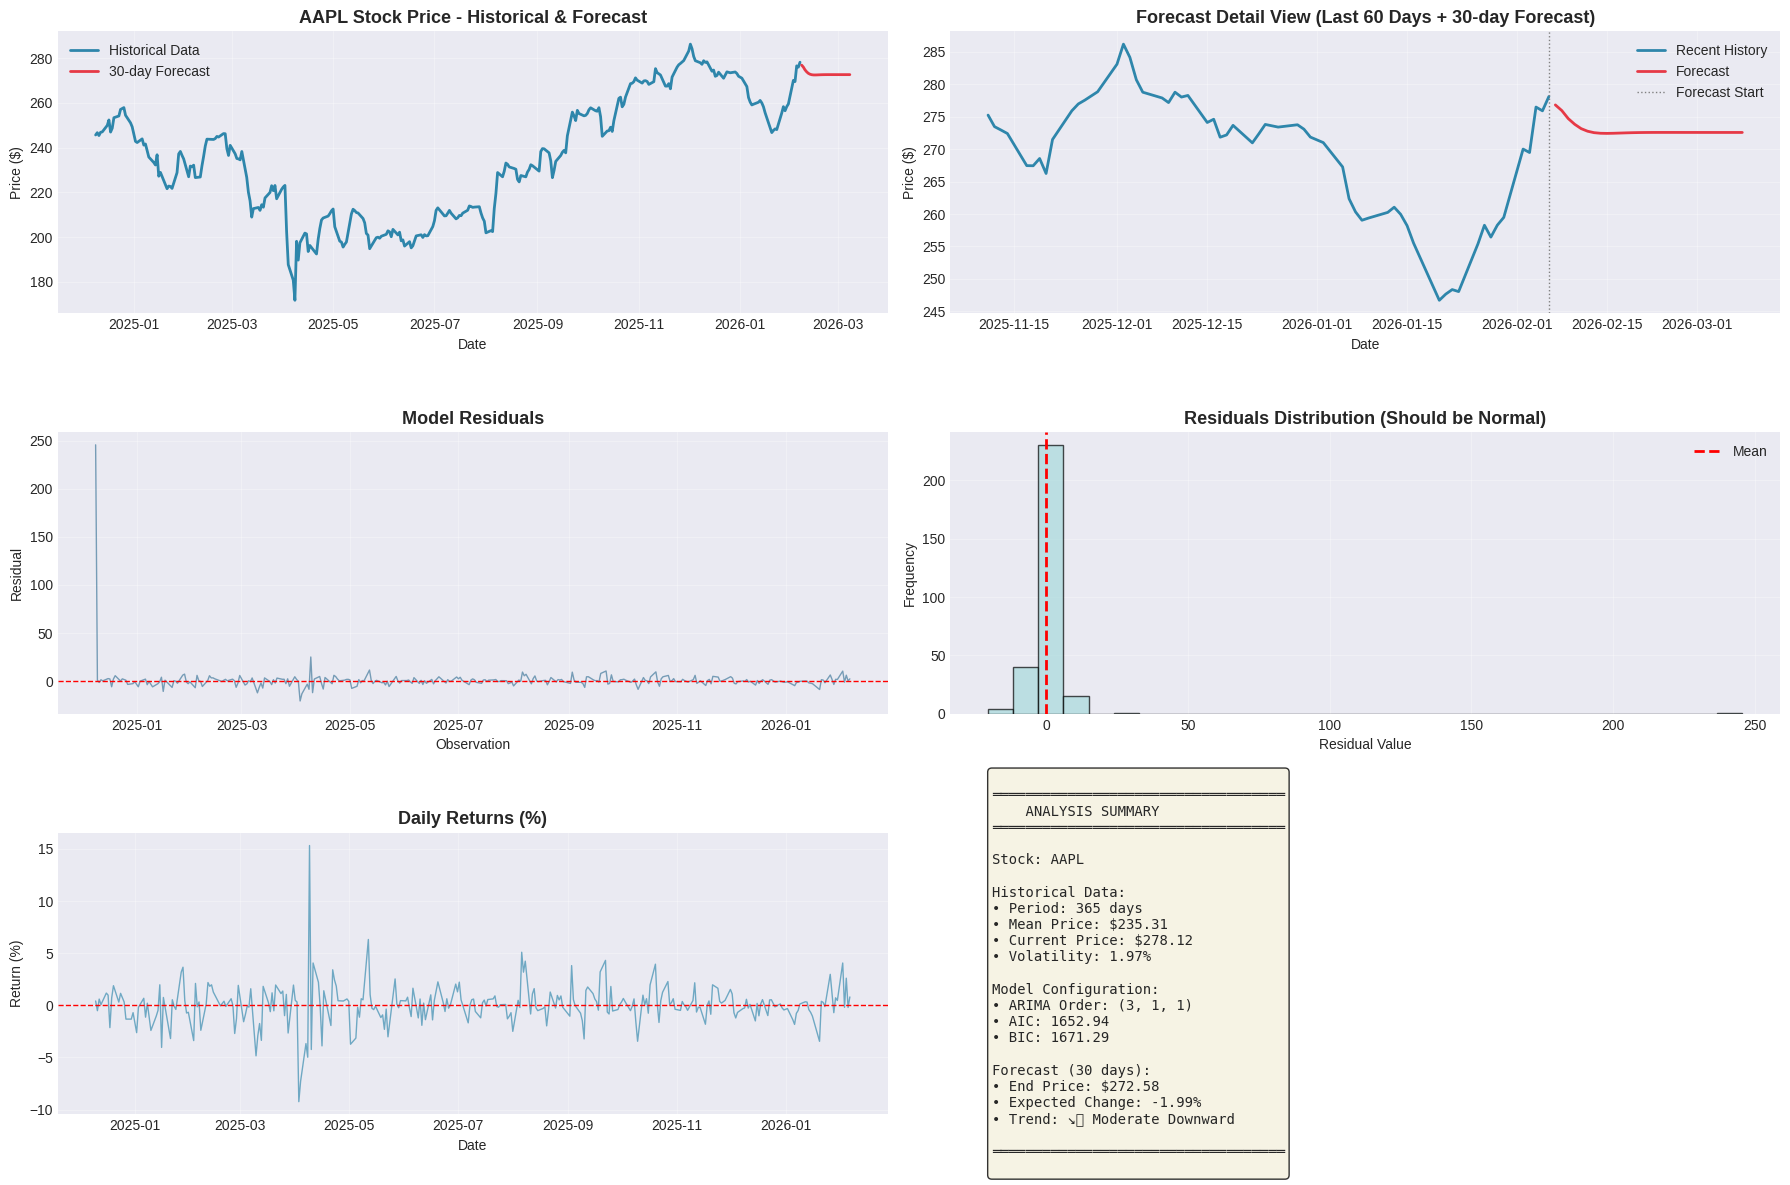

[07:52:01] ✅ Visualizations created successfully!


In [24]:
print_header("STEP 8: VISUALIZATION")

log_message("Creating comprehensive visualizations...", "PROCESS")

fig = plt.figure(figsize=(18, 12))

# 1. Historical Data with Forecast
ax1 = plt.subplot(3, 2, 1)
ax1.plot(ts_data.index, ts_data['Price'], label='Historical Data', linewidth=2, color='#2E86AB')
ax1.plot(forecast_df.index, forecast_df['Forecast'],
        label=f'{FORECAST_DAYS}-day Forecast', linewidth=2, linestyle='-', color='#E63946')
ax1.set_title(f'{STOCK_SYMBOL} Stock Price - Historical & Forecast', fontsize=13, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# 2. Zoomed Forecast View
ax2 = plt.subplot(3, 2, 2)
last_60_days = ts_data.tail(60)
ax2.plot(last_60_days.index, last_60_days['Price'], label='Recent History', linewidth=2, color='#2E86AB')
ax2.plot(forecast_df.index, forecast_df['Forecast'],
        label='Forecast', linewidth=2, linestyle='-', color='#E63946')
ax2.axvline(x=ts_data.index[-1], color='gray', linestyle=':', linewidth=1, label='Forecast Start')
ax2.set_title(f'Forecast Detail View (Last 60 Days + {FORECAST_DAYS}-day Forecast)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price ($)')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# 3. Model Residuals
ax3 = plt.subplot(3, 2, 3)
residuals = model_fit.resid
ax3.plot(residuals, linewidth=1, color='#457B9D', alpha=0.7)
ax3.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax3.set_title('Model Residuals', fontsize=13, fontweight='bold')
ax3.set_xlabel('Observation')
ax3.set_ylabel('Residual')
ax3.grid(True, alpha=0.3)

# 4. Residuals Distribution
ax4 = plt.subplot(3, 2, 4)
ax4.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='#A8DADC')
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Mean')
ax4.set_title('Residuals Distribution (Should be Normal)', fontsize=13, fontweight='bold')
ax4.set_xlabel('Residual Value')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Daily Returns
ax5 = plt.subplot(3, 2, 5)
returns = ts_data['Price'].pct_change() * 100
ax5.plot(returns, linewidth=1, alpha=0.7, color='#3b8db0')
ax5.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax5.set_title('Daily Returns (%)', fontsize=13, fontweight='bold')
ax5.set_xlabel('Date')
ax5.set_ylabel('Return (%)')
ax5.grid(True, alpha=0.3)

# 6. Information Panel
ax6 = plt.subplot(3, 2, 6)
ax6.axis('off')

# Determine trend
if forecast_pct_change > 5:
    trend_icon = "📈"
    trend_text = "Strong Upward"
elif forecast_pct_change > 0:
    trend_icon = "↗️"
    trend_text = "Moderate Upward"
elif forecast_pct_change > -5:
    trend_icon = "↘️"
    trend_text = "Moderate Downward"
else:
    trend_icon = "📉"
    trend_text = "Strong Downward"

info_text = f"""
{'═' * 35}
    ANALYSIS SUMMARY
{'═' * 35}

Stock: {STOCK_SYMBOL}

Historical Data:
• Period: {TRAINING_DAYS} days
• Mean Price: ${stats['mean']:.2f}
• Current Price: ${stats['last_price']:.2f}
• Volatility: {stats['volatility']:.2f}%

Model Configuration:
• ARIMA Order: {arima_order}
• AIC: {model_fit.aic:.2f}
• BIC: {model_fit.bic:.2f}

Forecast ({FORECAST_DAYS} days):
• End Price: ${forecast_values.iloc[-1]:.2f}
• Expected Change: {forecast_pct_change:+.2f}%
• Trend: {trend_icon} {trend_text}

{'═' * 35}
"""

ax6.text(0.05, 0.5, info_text, fontsize=10, verticalalignment='center',
        family='monospace', bbox=dict(boxstyle='round', facecolor='#F4F1DE', alpha=0.8))

plt.tight_layout()
plt.show()

log_message("Visualizations created successfully!", "SUCCESS")

# SECTION 12: COMPREHENSIVE ANALYSIS REPORT

In [20]:
print_header("COMPREHENSIVE ANALYSIS REPORT")

print(f"📅 Report Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"📊 Stock Analyzed: {STOCK_SYMBOL}\n")

print_separator()
print("1. DATA SUMMARY")
print_separator()
print(f"   Training Period     : {TRAINING_DAYS} days")
print(f"   Data Points         : {stats['count']}")
print(f"   Date Range          : {ts_data.index[0].strftime('%Y-%m-%d')} to {ts_data.index[-1].strftime('%Y-%m-%d')}")

print(f"\n{'-' * 80}")
print("2. PRICE STATISTICS")
print_separator()
print(f"   Mean Price          : ${stats['mean']:.2f}")
print(f"   Std Deviation       : ${stats['std']:.2f}")
print(f"   Min Price           : ${stats['min']:.2f}")
print(f"   Max Price           : ${stats['max']:.2f}")
print(f"   First Price         : ${stats['first_price']:.2f}")
print(f"   Last Price          : ${stats['last_price']:.2f}")
print(f"   Price Change        : ${stats['price_change']:+.2f}")
print(f"   Percentage Change   : {stats['pct_change']:+.2f}%")
print(f"   Daily Volatility    : {stats['volatility']:.2f}%")

print(f"\n{'-' * 80}")
print("3. STATIONARITY ANALYSIS")
print_separator()
print(f"   ADF P-value         : {adf_pvalue:.6f}")
print(f"   Is Stationary       : {'Yes' if is_stationary else 'No'}")
print(f"   Differencing Order  : {differencing_order}")

print(f"\n{'-' * 80}")
print("4. MODEL CONFIGURATION")
print_separator()
print(f"   Model Type          : ARIMA")
print(f"   Order (p,d,q)       : {arima_order}")
print(f"   AIC                 : {model_fit.aic:.4f}")
print(f"   BIC                 : {model_fit.bic:.4f}")
print(f"   HQIC                : {model_fit.hqic:.4f}")

if PERFORM_EVALUATION:
    print(f"\n{'-' * 80}")
    print("5. MODEL PERFORMANCE")
    print_separator()
    print(f"   Test Set Size       : {len(test)} observations")
    print(f"   RMSE                : ${rmse:.4f}")
    print(f"   MAE                 : ${mae:.4f}")
    print(f"   MAPE                : {mape:.2f}%")
    print(f"   Quality Rating      : {quality}")

print(f"\n{'-' * 80}")
print("6. FORECAST RESULTS")
print_separator()
print(f"   Forecast Horizon    : {FORECAST_DAYS} days")
print(f"   Current Price       : ${current_price:.2f}")
print(f"   Forecasted Price    : ${forecast_values.iloc[-1]:.2f}")
print(f"   Expected Change     : ${forecast_change:+.2f} ({forecast_pct_change:+.2f}%)")
print(f"   Trend               : {trend_text}")

print(f"\n{'-' * 80}")
print("7. BUSINESS INTERPRETATION")
print_separator()

if forecast_pct_change > 5:
    recommendation = "Strong buy signal - Consider accumulating positions"
    risk = "Monitor for overbought conditions"
elif forecast_pct_change > 0:
    recommendation = "Moderate buy signal - Stable growth expected"
    risk = "Normal market risk"
elif forecast_pct_change > -5:
    recommendation = "Hold or cautious sell - Slight downward pressure"
    risk = "Moderate downside risk"
else:
    recommendation = "Sell signal - Consider risk management strategies"
    risk = "High downside risk"

print(f"   Market Trend        : {trend_text}")
print(f"   Volatility Level    : {stats['volatility']:.2f}% daily")
print(f"   Recommendation      : {recommendation}")
print(f"   Risk Assessment     : {risk}")

print(f"\n{'-' * 80}")
print("8. KEY FINDINGS")
print_separator()
print(f"   • {STOCK_SYMBOL} shows a {trend_text.lower()} trend over next {FORECAST_DAYS} days")
if PERFORM_EVALUATION:
    print(f"   • Model achieved MAPE of {mape:.2f}% on test data")
print(f"   • Daily volatility of {stats['volatility']:.2f}% indicates {'high' if stats['volatility'] > 2 else 'moderate'} risk")
print(f"   • ARIMA{arima_order} model selected as best fit")
print(f"   • Expected price movement: {forecast_pct_change:+.2f}%")

print(f"\n{'-' * 80}")
print("9. LIMITATIONS & CONSIDERATIONS")
print_separator()
print("   Limitations:")
print("   • ARIMA assumes linear relationships and may miss complex patterns")
print("   • Does not account for external factors (news, market events)")
print("   • Forecast accuracy decreases for longer time horizons")
print("   • Past performance does not guarantee future results")
print("\n   Considerations:")
print("   • Combine with fundamental analysis for better decisions")
print("   • Monitor market news and economic indicators")
print("   • Use appropriate risk management strategies")

print(f"\n{'-' * 80}")
print("10. FUTURE IMPROVEMENTS")
print_separator()
print("   • Implement SARIMA for seasonal patterns")
print("   • Add exogenous variables (market indices, volume)")
print("   • Ensemble with LSTM/Prophet for better accuracy")
print("   • Incorporate sentiment analysis from news/social media")

print("\n" + "=" * 80)
print("END OF REPORT".center(80))
print("=" * 80 + "\n")


                         COMPREHENSIVE ANALYSIS REPORT                          

📅 Report Generated: 2026-02-07 07:46:56
📊 Stock Analyzed: AAPL

────────────────────────────────────────────────────────────────────────────────
1. DATA SUMMARY
────────────────────────────────────────────────────────────────────────────────
   Training Period     : 365 days
   Data Points         : 291
   Date Range          : 2024-12-09 to 2026-02-06

--------------------------------------------------------------------------------
2. PRICE STATISTICS
────────────────────────────────────────────────────────────────────────────────
   Mean Price          : $235.31
   Std Deviation       : $26.38
   Min Price           : $171.83
   Max Price           : $286.19
   First Price         : $245.64
   Last Price          : $278.12
   Price Change        : $+32.48
   Percentage Change   : +13.22%
   Daily Volatility    : 1.97%

--------------------------------------------------------------------------------
3. 

# SECTION 13: SAVE RESULTS

In [21]:
if SAVE_RESULTS:
    print_header("SAVING RESULTS")

    try:
        # Save forecast to CSV
        filename = f'{STOCK_SYMBOL}_forecast_{datetime.now().strftime("%Y%m%d_%H%M%S")}.csv'
        forecast_df.to_csv(filename)
        log_message(f"Forecast saved to: {filename}", "SUCCESS")

        # Display first few rows
        print("\n📊 Forecast Preview:")
        print(forecast_df.head(10))

    except Exception as e:
        log_message(f"Error saving results: {str(e)}", "ERROR")


                                 SAVING RESULTS                                 

[07:47:37] ✅ Forecast saved to: AAPL_forecast_20260207_074737.csv

📊 Forecast Preview:
                             Forecast
Date                                 
2026-02-07 00:00:00-05:00  276.821390
2026-02-08 00:00:00-05:00  275.950265
2026-02-09 00:00:00-05:00  274.712160
2026-02-10 00:00:00-05:00  273.834769
2026-02-11 00:00:00-05:00  273.165367
2026-02-12 00:00:00-05:00  272.764977
2026-02-13 00:00:00-05:00  272.541846
2026-02-14 00:00:00-05:00  272.449201
2026-02-15 00:00:00-05:00  272.429870
2026-02-16 00:00:00-05:00  272.448815


# SECTION 14: SUMMARY & NEXT STEPS

In [22]:
print_header("ANALYSIS COMPLETE")

print("""
✨ Analysis completed successfully!

📝 To customize the analysis, modify the configuration parameters in SECTION 2:
   • Change STOCK_SYMBOL to analyze different stocks
   • Adjust TRAINING_DAYS for different historical periods
   • Modify FORECAST_DAYS for different forecast horizons
   • Toggle AUTO_ORDER for automatic parameter selection

📊 Access results programmatically:
   • Historical data: ts_data
   • Forecast data: forecast_df
   • Model object: model_fit
   • Statistics: stats dictionary

💾 Export options:
   • CSV: forecast_df.to_csv('my_forecast.csv')
   • Excel: forecast_df.to_excel('my_forecast.xlsx')

🔄 To run analysis for multiple stocks, wrap the code in a function or loop

⚠️  Important: This is for educational purposes only. Not financial advice!
""")

print("=" * 80)
print("Thank you for using the ARIMA Stock Forecasting Model!".center(80))
print("=" * 80)


                               ANALYSIS COMPLETE                                


✨ Analysis completed successfully!

📝 To customize the analysis, modify the configuration parameters in SECTION 2:
   • Change STOCK_SYMBOL to analyze different stocks
   • Adjust TRAINING_DAYS for different historical periods
   • Modify FORECAST_DAYS for different forecast horizons
   • Toggle AUTO_ORDER for automatic parameter selection
   
📊 Access results programmatically:
   • Historical data: ts_data
   • Forecast data: forecast_df
   • Model object: model_fit
   • Statistics: stats dictionary
   
💾 Export options:
   • CSV: forecast_df.to_csv('my_forecast.csv')
   • Excel: forecast_df.to_excel('my_forecast.xlsx')
   
🔄 To run analysis for multiple stocks, wrap the code in a function or loop

⚠️  Important: This is for educational purposes only. Not financial advice!

             Thank you for using the ARIMA Stock Forecasting Model!             
